# Avance del Proyecto — Fase 1

## Exploración inteligente para la Ciencia de Datos (MCDI503)

**Título del avance:** Análisis exploratorio reproducible del dataset Titanic — Fase 1: implementación inicial del EDA

**Integrantes del equipo (Grupo 5):**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Dataset utilizado:** `Titanic-Dataset.csv` (891 registros, 12 variables), correspondiente a los pasajeros del RMS Titanic en su viaje inaugural del 15 de abril de 1912.

**Propósito general del análisis:** Realizar un primer ciclo de análisis exploratorio de datos (EDA) reproducible sobre el dataset Titanic, evidenciando la carga, revisión de calidad y exploración preliminar de las variables disponibles, como base técnica para el desarrollo de fases posteriores del proyecto (que podrían orientarse a la estimación de la probabilidad de supervivencia de un pasajero).

Este notebook se organiza en 8 apartados, conforme a la estructura definida para la Fase 1: (I) Identificación del proyecto, (II) Contexto y objetivo exploratorio, (III) Carga y revisión inicial de datos, (IV) Exploración preliminar, (V) Decisiones y transformaciones iniciales, (VI) Resultados e interpretación inicial, (VII) Supuestos y limitaciones, (VIII) Cierre del avance.

---
## I. Identificación del proyecto

| Campo | Detalle |
|---|---|
| Título del proyecto | Análisis exploratorio reproducible del dataset Titanic — Fase 1 |
| Curso | MCDI503 — Exploración inteligente para la ciencia de datos |
| Fase | Fase 1 — Implementación inicial del EDA reproducible |
| Integrantes | Arturo Knopke Vera, Nicolás Soletic Cobos, Sebastián Navarrete Soto, Roberto Moncada González |
| Dataset | `data/Titanic-Dataset.csv` (fuente: Kaggle, *Titanic - Machine Learning from Disaster*) |
| Propósito general | Establecer un primer ciclo de EDA reproducible, documentado y trazable sobre el dataset Titanic |


---
## II. Contexto y objetivo exploratorio

### Contexto breve del problema abordado

El hundimiento del RMS Titanic, ocurrido el 15 de abril de 1912 durante su viaje inaugural tras colisionar con un iceberg, es uno de los naufragios más conocidos de la historia moderna. De las 2224 personas a bordo, murieron 1502, en gran parte porque no había botes salvavidas suficientes para todos los pasajeros y tripulantes. Aunque la supervivencia tuvo un componente de azar, existe evidencia de que ciertos grupos de pasajeros (por sexo, clase de pasaje, edad, entre otros) tuvieron mayor probabilidad de sobrevivir que otros.

El dataset trabajado corresponde a un subconjunto de 891 pasajeros con 12 variables registradas (identificador, supervivencia, clase de pasaje, nombre, sexo, edad, familiares a bordo, tarifa, cabina, puerto de embarque, entre otras), que permite abordar un diagnóstico de calidad de datos, transformación de variables y análisis univariado y bivariado.

### Objetivo exploratorio del avance

Implementar un primer ciclo de análisis exploratorio de datos reproducible sobre el dataset Titanic, que permita: (a) caracterizar técnicamente la estructura y calidad del conjunto de datos, (b) identificar patrones preliminares de asociación entre las variables disponibles y la supervivencia de los pasajeros, y (c) dejar documentadas las decisiones, supuestos y limitaciones que orientarán las fases posteriores del proyecto.

### Preguntas exploratorias iniciales

1. ¿Cuál es la estructura general del dataset (dimensiones, tipos de variables, completitud)?
2. ¿Cómo se distribuye la tasa de supervivencia global y según variables categóricas clave (sexo, clase de pasaje, puerto de embarque)?
3. ¿Existen diferencias visibles en variables numéricas (edad, tarifa, tamaño del grupo familiar) entre pasajeros que sobrevivieron y los que no?
4. ¿Qué variables presentan valores faltantes relevantes y cómo deberían tratarse en esta primera etapa?
5. ¿Se observan valores atípicos evidentes en variables numéricas continuas como `Fare` y `Age`?

### Alcance del trabajo realizado en esta fase

Este avance cubre la carga y revisión inicial del dataset, la exploración descriptiva univariada y bivariada, la construcción de un pequeño conjunto de variables derivadas útiles para el análisis (tamaño familiar, indicador de viajar solo, título extraído del nombre, indicador de cabina registrada), y la síntesis de los primeros hallazgos. **No se realiza en esta fase** imputación definitiva de valores faltantes, ingeniería de variables final, partición train/test ni modelado predictivo: estas actividades quedan para fases posteriores del proyecto.

### Supuestos iniciales y limitaciones preliminares

- El archivo `Titanic-Dataset.csv` corresponde a un subconjunto de 891 pasajeros (no censal), sin tripulación; no se asume que represente la totalidad de personas a bordo.
- Se asume que los valores faltantes en `Age` podrían estar asociados a variables observadas (posible relación con clase de pasaje o tarifa), por lo que su tratamiento definitivo se pospone; los 2 casos faltantes de `Embarked` se tratan de manera puntual en esta fase.
- Limitación preliminar: `Cabin` presenta un porcentaje muy alto de valores faltantes (~77%), lo que restringe su utilidad directa en este ciclo exploratorio.

---
## III. Carga y revisión inicial de datos

Se importan las librerías necesarias para el análisis (`pandas`, `numpy`, `matplotlib`, `seaborn`) y se carga el dataset desde `data/Titanic-Dataset.csv`. A continuación se revisa la estructura básica: número de filas y columnas, tipos de datos por variable y una primera vista de los registros.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

RUTA_DATOS = "../data/Titanic-Dataset.csv"
RUTA_FIGURAS = "../figures"

titanic = pd.read_csv(RUTA_DATOS)
print("Dimensiones del dataset:", titanic.shape)
titanic.head()

Dimensiones del dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Primeras observaciones sobre variables, tipos de datos y estado general del dataset

- El dataset contiene **891 filas y 12 columnas**.
- Existen variables numéricas continuas (`Age`, `Fare`), numéricas discretas (`SibSp`, `Parch`, `Pclass`, `Survived` como binaria), y variables de texto/categóricas (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`).
- `PassengerId` es un identificador único sin valor analítico directo.
- A simple vista, `Age`, `Cabin` y `Embarked` muestran menos registros no nulos que el total de filas, lo que anticipa valores faltantes que se cuantifican a continuación.

In [3]:
faltantes = titanic.isna().sum().sort_values(ascending=False)
porcentaje = (titanic.isna().mean() * 100).round(2).sort_values(ascending=False)
resumen_faltantes = pd.DataFrame({"n_faltantes": faltantes, "pct_faltantes": porcentaje})
resumen_faltantes = resumen_faltantes[resumen_faltantes["n_faltantes"] > 0]
resumen_faltantes

,n_faltantes,pct_faltantes
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Estado general de calidad de datos detectado:**

- `Cabin`: 687 valores faltantes (77.1%) — variable con calidad insuficiente para uso directo en esta fase.
- `Age`: 177 valores faltantes (19.9%) — proporción relevante que requiere tratamiento cuidadoso en fases posteriores.
- `Embarked`: 2 valores faltantes (0.22%) — impacto marginal dado el tamaño de la muestra.
- El resto de las variables (`Survived`, `Pclass`, `Sex`, `SibSp`, `Parch`, `Fare`, `Ticket`, `Name`) no presenta valores faltantes.

---
## IV. Exploración preliminar

Se construyen resúmenes descriptivos iniciales para variables numéricas y categóricas, y se generan las primeras visualizaciones para observar el comportamiento general del dataset, sin todavía relacionar formalmente las variables entre sí (eso se aborda en el apartado VI).

In [4]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"\nFrecuencias de {col}:")
    print(titanic[col].value_counts(dropna=False))


Frecuencias de Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Frecuencias de Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Frecuencias de Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Frecuencias de Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


**Revisión preliminar de variables relevantes:**

- `Survived`: variable objetivo de futuras fases (0 = no sobrevivió, 1 = sobrevivió). De los 891 pasajeros, sobrevivió el 38.4% (342 de 891).
- `Pclass`: distribución desbalanceada hacia la tercera clase (55.1% de los pasajeros), seguida de primera (24.2%) y segunda (20.7%).
- `Sex`: predominan pasajeros hombres (64.8%) sobre mujeres (35.2%).
- `Embarked`: la mayoría embarcó en Southampton (`S`, 72.4%), seguido de Cherbourg (`C`, 18.9%) y Queenstown (`Q`, 8.6%), con 2 casos sin registrar.

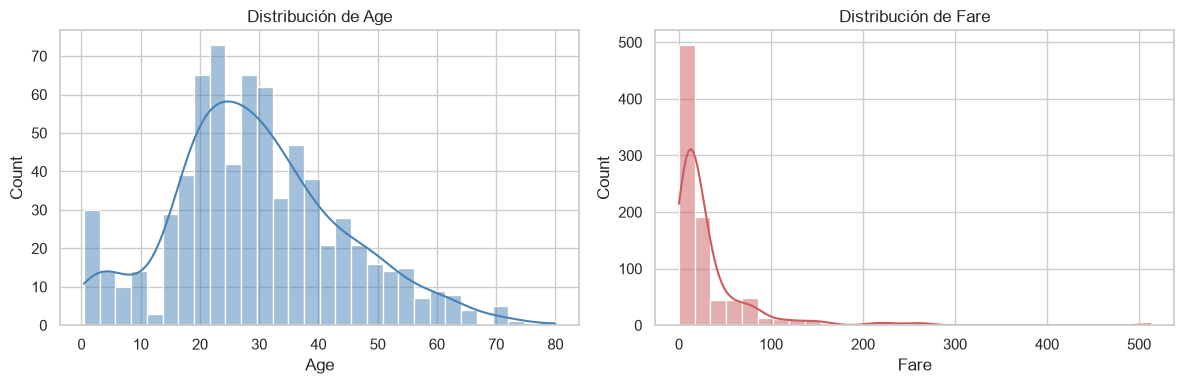

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(titanic["Age"].dropna(), kde=True, ax=axes[0], color="steelblue", bins=30)
axes[0].set_title("Distribución de Age")

sns.histplot(titanic["Fare"], kde=True, ax=axes[1], color="indianred", bins=30)
axes[1].set_title("Distribución de Fare")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_dist_age_fare.png", dpi=150, bbox_inches="tight")
plt.show()

`Age` muestra una distribución aproximadamente centrada entre los 20 y 40 años, con una cola hacia edades mayores. `Fare` presenta una fuerte asimetría a la derecha, con la mayoría de las tarifas concentradas en valores bajos y unos pocos pasajeros con tarifas muy altas, lo que anticipa la presencia de valores atípicos (se revisa más adelante con IQR).

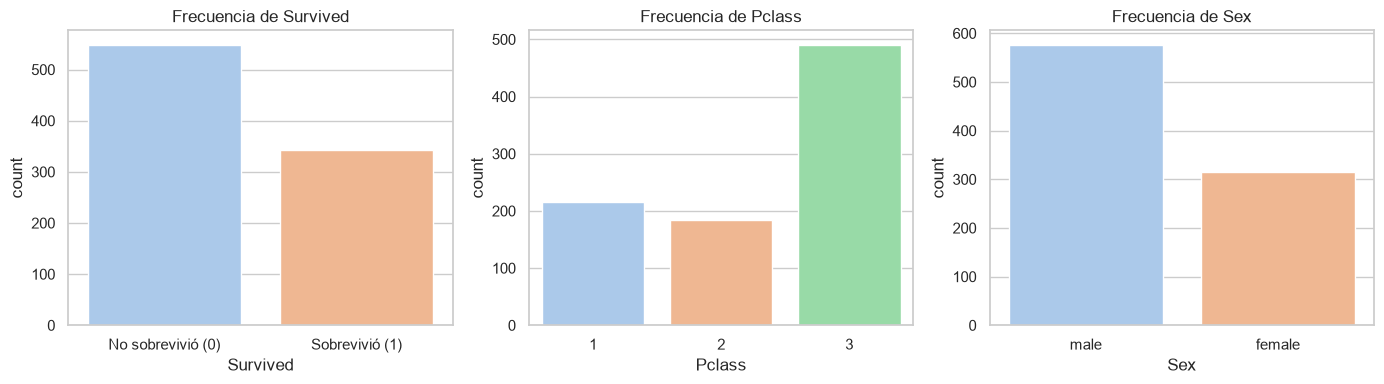

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=titanic, x="Survived", hue="Survived", legend=False, palette="pastel", ax=axes[0])
axes[0].set_title("Frecuencia de Survived")
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"])

sns.countplot(data=titanic, x="Pclass", hue="Pclass", legend=False, palette="pastel", ax=axes[1])
axes[1].set_title("Frecuencia de Pclass")

sns.countplot(data=titanic, x="Sex", hue="Sex", legend=False, palette="pastel", ax=axes[2])
axes[2].set_title("Frecuencia de Sex")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_frecuencias_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

Estas salidas iniciales confirman de forma visual lo observado en las tablas de frecuencias: predominio de pasajeros de tercera clase, predominio de hombres, y una tasa de supervivencia global minoritaria (menos del 40% del total).

---
## V. Decisiones y transformaciones iniciales

En este apartado se documentan las decisiones exploratorias adoptadas en este primer ciclo, su justificación y las transformaciones (variables derivadas) construidas para apoyar el análisis bivariado del siguiente apartado. **No se realiza imputación definitiva** de valores faltantes: las decisiones aquí son diagnósticas y de preparación mínima, no la estrategia final de preprocesamiento.

### Decisión 1 — `Cabin`: no imputar, crear indicador de registro

*Por qué:* con 77.1% de valores faltantes, cualquier imputación de la cabina específica sería poco confiable y podría introducir ruido. En cambio, la sola ausencia o presencia del dato puede ser informativa (los registros de cabina suelen estar asociados a pasajes de mayor categoría).

*Transformación:* se crea la variable binaria `Cabin_registrada` (1 si `Cabin` no es nulo, 0 en caso contrario).

### Decisión 2 — `Age`: mantener valores faltantes, sin imputar en esta fase

*Por qué:* el 19.9% de datos faltantes es demasiado relevante para imputar sin un análisis más profundo de su relación con otras variables (p. ej., `Pclass`, `Title`). Imputar prematuramente podría sesgar los hallazgos exploratorios iniciales.

*Transformación:* se crea la variable binaria `Age_registrada` como indicador de completitud, y se calculan —solo con fines diagnósticos— la mediana de edad y el porcentaje de valores faltantes de `Age` por `Pclass`; la primera se usará como referencia en fases posteriores.

### Decisión 3 — `Embarked`: imputar los 2 casos faltantes con la moda

*Por qué:* el impacto de 2 registros sobre 891 es marginal (0.22%) y no distorsiona la distribución general; se opta por una imputación simple con la moda (`S`) para evitar pérdida de filas en análisis bivariados posteriores.

*Transformación:* se genera `Embarked_imputado`, copia de `Embarked` con los 2 valores faltantes reemplazados por la moda.

### Decisión 4 — Construcción de `FamilySize` e `IsAlone`

*Por qué:* `SibSp` (hermanos/cónyuges) y `Parch` (padres/hijos) por separado dificultan observar el efecto del tamaño del grupo familiar sobre la supervivencia. Se combinan en una sola variable interpretable.

*Transformación:* `FamilySize = SibSp + Parch + 1` (incluye al propio pasajero); `IsAlone = 1` si `FamilySize == 1`.

### Decisión 5 — Extracción de `Title` desde `Name`

*Por qué:* el nombre completo no es utilizable directamente, pero el tratamiento (Mr., Mrs., Miss., Master., etc.) condensa información demográfica (edad aproximada, sexo, estado civil, estatus social) potencialmente asociada a la supervivencia.

*Transformación:* se extrae el título mediante una expresión regular sobre `Name` y se agrupan los títulos poco frecuentes en la categoría `Other`.

In [8]:
titanic_exp = titanic.copy()

# Decisión 1: indicador de cabina registrada
titanic_exp["Cabin_registrada"] = titanic_exp["Cabin"].notna().astype(int)

# Decisión 2: indicador de edad registrada + mediana de edad por clase (solo diagnóstico)
titanic_exp["Age_registrada"] = titanic_exp["Age"].notna().astype(int)
mediana_edad_por_clase = titanic_exp.groupby("Pclass")["Age"].median()
pct_age_faltante_por_clase = (titanic_exp.groupby("Pclass")["Age"].apply(lambda s: s.isna().mean() * 100)).round(1)

# Decisión 3: imputación puntual de Embarked (2 casos) con la moda
moda_embarked = titanic_exp["Embarked"].mode(dropna=True)[0]
titanic_exp["Embarked_imputado"] = titanic_exp["Embarked"].fillna(moda_embarked)

# Decisión 4: tamaño de familia e indicador de viajar solo
titanic_exp["FamilySize"] = titanic_exp["SibSp"] + titanic_exp["Parch"] + 1
titanic_exp["IsAlone"] = (titanic_exp["FamilySize"] == 1).astype(int)

# Decisión 5: título extraído del nombre
titanic_exp["Title"] = titanic_exp["Name"].str.extract(r",\s*([^\.]+)\.")
titulos_frecuentes = titanic_exp["Title"].value_counts()
titulos_a_conservar = titulos_frecuentes[titulos_frecuentes >= 10].index
titanic_exp["Title"] = titanic_exp["Title"].where(titanic_exp["Title"].isin(titulos_a_conservar), "Other")

print("Mediana de Age por Pclass (referencia diagnóstica, sin imputar aún):")
print(mediana_edad_por_clase)
print("\nPorcentaje de Age faltante por Pclass:")
print(pct_age_faltante_por_clase)
print(f"\nModa utilizada para imputar Embarked: '{moda_embarked}' (2 casos reemplazados)")
print("\nDistribución de Title tras agrupar categorías poco frecuentes:")
print(titanic_exp["Title"].value_counts())

Mediana de Age por Pclass (referencia diagnóstica, sin imputar aún):
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

Porcentaje de Age faltante por Pclass:
Pclass
1    13.9
2     6.0
3    27.7
Name: Age, dtype: float64

Moda utilizada para imputar Embarked: 'S' (2 casos reemplazados)

Distribución de Title tras agrupar categorías poco frecuentes:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


In [9]:
titanic_exp[["Name", "Title", "Sex", "Age", "Age_registrada", "Cabin_registrada",
             "SibSp", "Parch", "FamilySize", "IsAlone", "Embarked", "Embarked_imputado"]].head(8)

,Name,Title,Sex,Age,Age_registrada,Cabin_registrada,SibSp,Parch,FamilySize,IsAlone,Embarked,Embarked_imputado
0,"Braund, Mr. Owen Harris",Mr,male,22.0,1,0,1,0,2,0,S,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,female,38.0,1,1,1,0,2,0,C,C
2,"Heikkinen, Miss. Laina",Miss,female,26.0,1,0,0,0,1,1,S,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,female,35.0,1,1,1,0,2,0,S,S
4,"Allen, Mr. William Henry",Mr,male,35.0,1,0,0,0,1,1,S,S
5,"Moran, Mr. James",Mr,male,NaN,0,0,0,0,1,1,Q,Q
6,"McCarthy, Mr. Timothy J",Mr,male,54.0,1,1,0,0,1,1,S,S
7,"Palsson, Master. Gosta Leonard",Master,male,2.0,1,0,3,1,5,0,S,S


**Resultados intermedios de las transformaciones:** el dataset ampliado (`titanic_exp`) conserva las 891 filas originales y agrega 6 columnas derivadas. La proporción de valores faltantes de `Age` varía entre clases (13.9% en primera, 6.0% en segunda, 27.7% en tercera), lo que sugiere que la ausencia podría estar asociada a variables observadas como `Pclass`; esto refuerza la decisión de posponer su imputación definitiva hasta contar con un análisis más detallado. La mediana de edad por `Pclass` (más alta en primera clase, más baja en tercera) queda como referencia para esa imputación. Los títulos agrupados (`Mr`, `Miss`, `Mrs`, `Master`, `Other`) muestran una distribución interpretable y coherente con la composición demográfica esperada del pasaje.

---
## VI. Resultados e interpretación inicial

Se retoman las preguntas exploratorias iniciales y se contrastan con los resultados obtenidos a partir de comparaciones bivariadas entre las variables disponibles (incluidas las derivadas) y `Survived`. Las preguntas 1 (estructura y completitud) y 4 (valores faltantes) quedaron respondidas en los apartados III y V, respectivamente; este apartado se concentra en las preguntas 2, 3 y 5.

In [10]:
tasa_supervivencia_sexo = titanic_exp.groupby("Sex")["Survived"].mean().round(3)
tasa_supervivencia_clase = titanic_exp.groupby("Pclass")["Survived"].mean().round(3)
tasa_supervivencia_embarque = titanic_exp.groupby("Embarked_imputado")["Survived"].mean().round(3)

print("Tasa de supervivencia por Sex:\n", tasa_supervivencia_sexo)
print("\nTasa de supervivencia por Pclass:\n", tasa_supervivencia_clase)
print("\nTasa de supervivencia por puerto de embarque:\n", tasa_supervivencia_embarque)

Tasa de supervivencia por Sex:
 Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Tasa de supervivencia por Pclass:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Tasa de supervivencia por puerto de embarque:
 Embarked_imputado
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


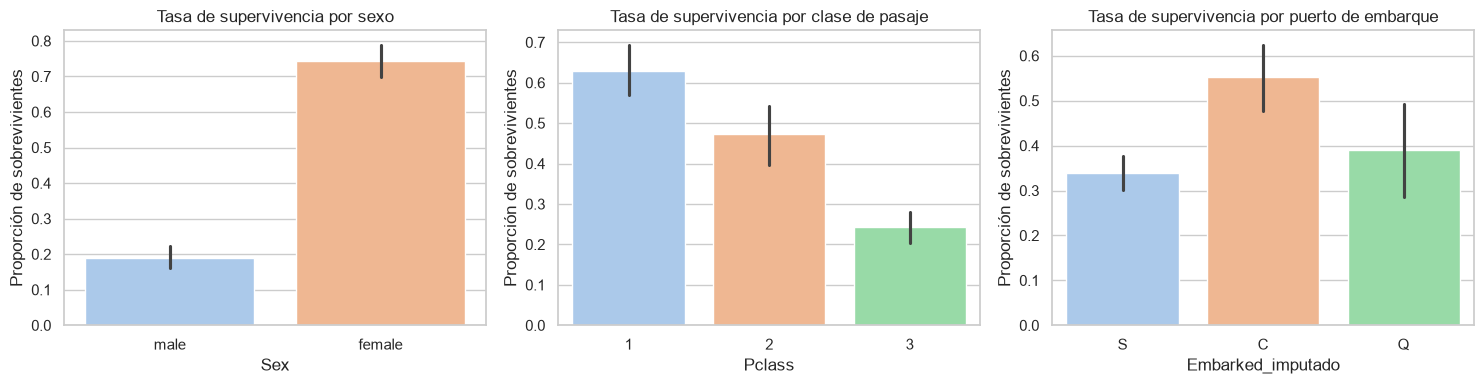

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=titanic_exp, x="Sex", y="Survived", hue="Sex", legend=False, palette="pastel", ax=axes[0])
axes[0].set_title("Tasa de supervivencia por sexo")
axes[0].set_ylabel("Proporción de sobrevivientes")

sns.barplot(data=titanic_exp, x="Pclass", y="Survived", hue="Pclass", legend=False, palette="pastel", ax=axes[1])
axes[1].set_title("Tasa de supervivencia por clase de pasaje")
axes[1].set_ylabel("Proporción de sobrevivientes")

sns.barplot(data=titanic_exp, x="Embarked_imputado", y="Survived", hue="Embarked_imputado", legend=False, palette="pastel", ax=axes[2])
axes[2].set_title("Tasa de supervivencia por puerto de embarque")
axes[2].set_ylabel("Proporción de sobrevivientes")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_supervivencia_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación (pregunta 2 — variables categóricas):** la tasa de supervivencia difiere marcadamente por sexo (mujeres ≈74% vs. hombres ≈19%) y por clase de pasaje (primera ≈63%, segunda ≈47%, tercera ≈24%), consistente con el patrón histórico de prioridad de evacuación. La diferencia por puerto de embarque es menor y probablemente está confundida con la composición de clases de cada puerto (se deja como hipótesis para fases posteriores).

Mediana y media de Age, Fare y FamilySize según Survived:
             Age          Fare        FamilySize      
         median   mean median   mean     median  mean
Survived                                             
0          28.0  30.63   10.5  22.12        1.0  1.88
1          28.0  28.34   26.0  48.40        2.0  1.94


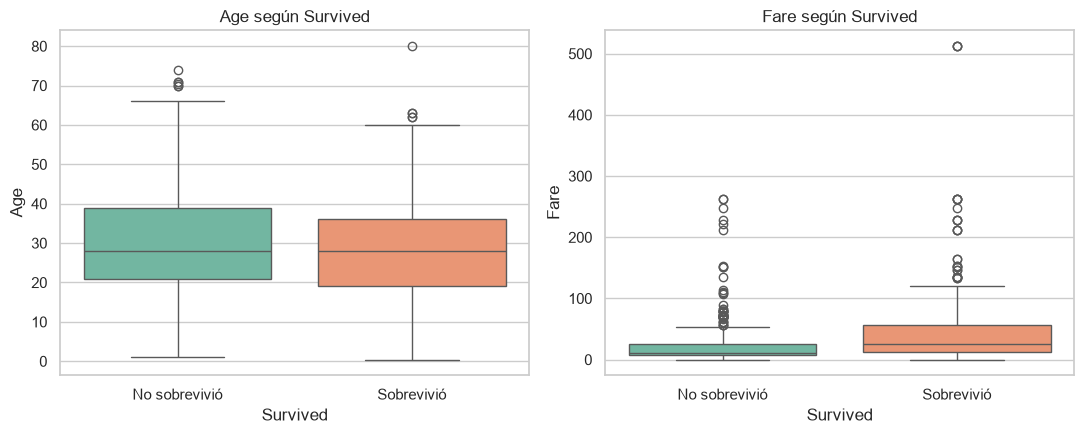

In [12]:
descriptivos_por_grupo = titanic_exp.groupby("Survived")[["Age", "Fare", "FamilySize"]].agg(["median", "mean"]).round(2)
print("Mediana y media de Age, Fare y FamilySize según Survived:\n", descriptivos_por_grupo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=titanic_exp, x="Survived", y="Age", hue="Survived", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Age según Survived")
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(["No sobrevivió", "Sobrevivió"])

sns.boxplot(data=titanic_exp, x="Survived", y="Fare", hue="Survived", legend=False, palette="Set2", ax=axes[1])
axes[1].set_title("Fare según Survived")
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(["No sobrevivió", "Sobrevivió"])

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_boxplots_survived.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación (pregunta 3 — variables numéricas):** la distribución de `Age` es similar entre ambos grupos, con una mediana de 28 años en ambos casos; la media es algo menor entre quienes sobrevivieron (28.34 frente a 30.63 años), por lo que la diferencia observada es acotada y debe leerse de forma descriptiva. `Fare` sí muestra una diferencia visible: quienes sobrevivieron pagaron tarifas más altas (mediana 26.0 frente a 10.5), coherente con la asociación observada entre clase de pasaje y supervivencia. `FamilySize` presenta una diferencia modesta (mediana 2 frente a 1; media 1.94 frente a 1.88), que se examina con más detalle mediante `IsAlone` más adelante.

In [13]:
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    mask = (serie < li) | (serie > ls)
    return {
        "q1": q1, "q3": q3, "iqr": iqr,
        "limite_inferior": li, "limite_superior": ls,
        "n_outliers": int(mask.sum()),
        "pct_outliers": round(100 * mask.sum() / serie.notna().sum(), 2),
    }

print("Outliers en Fare (IQR):", detectar_outliers_iqr(titanic_exp["Fare"]))
print("Outliers en Age (IQR):", detectar_outliers_iqr(titanic_exp["Age"].dropna()))

Outliers en Fare (IQR): {'q1': np.float64(7.9104), 'q3': np.float64(31.0), 'iqr': np.float64(23.0896), 'limite_inferior': np.float64(-26.724), 'limite_superior': np.float64(65.6344), 'n_outliers': 116, 'pct_outliers': np.float64(13.02)}
Outliers en Age (IQR): {'q1': np.float64(20.125), 'q3': np.float64(38.0), 'iqr': np.float64(17.875), 'limite_inferior': np.float64(-6.6875), 'limite_superior': np.float64(64.8125), 'n_outliers': 11, 'pct_outliers': np.float64(1.54)}


**Interpretación (pregunta 5 — outliers):** `Fare` presenta una proporción relevante de valores atípicos por sobre el límite superior (tarifas muy altas asociadas probablemente a camarotes de primera clase o grupos familiares que compartieron un mismo boleto), mientras que `Age` presenta una proporción baja de valores atípicos, concentrados en edades avanzadas. Estos casos no se remueven en esta fase: se documentan como candidatos a revisión en el tratamiento de datos de la siguiente fase.

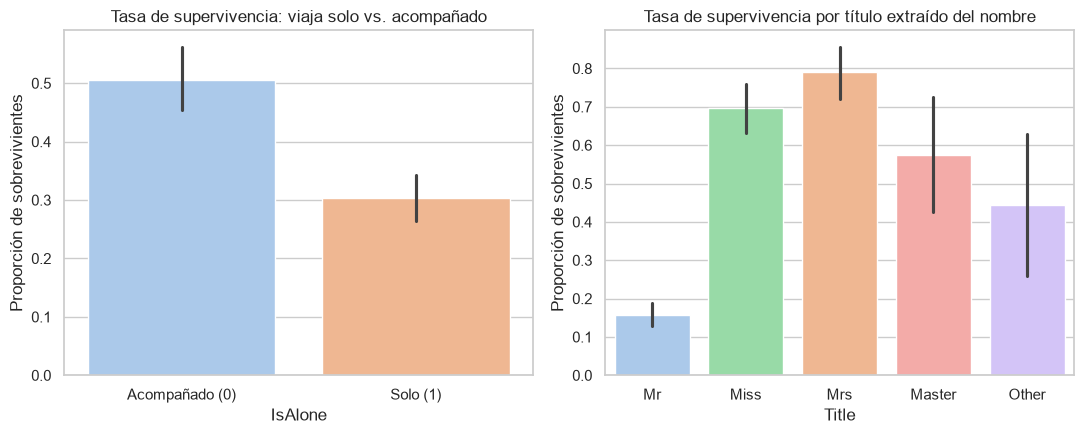

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=titanic_exp, x="IsAlone", y="Survived", hue="IsAlone", legend=False, palette="pastel", ax=axes[0])
axes[0].set_title("Tasa de supervivencia: viaja solo vs. acompañado")
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(["Acompañado (0)", "Solo (1)"])
axes[0].set_ylabel("Proporción de sobrevivientes")

sns.barplot(data=titanic_exp, x="Title", y="Survived", hue="Title", legend=False, palette="pastel", ax=axes[1],
            order=titanic_exp["Title"].value_counts().index)
axes[1].set_title("Tasa de supervivencia por título extraído del nombre")
axes[1].set_ylabel("Proporción de sobrevivientes")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_familia_titulo.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación (continuación pregunta 3 — composición familiar):** las variables derivadas también muestran señal exploratoria: viajar solo se asocia a una menor tasa de supervivencia que viajar acompañado, y el título extraído del nombre (que combina sexo, edad aproximada y estatus) reproduce con más matiz el patrón observado por sexo y clase (`Mrs` y `Miss` con tasas altas, `Mr` con la tasa más baja).

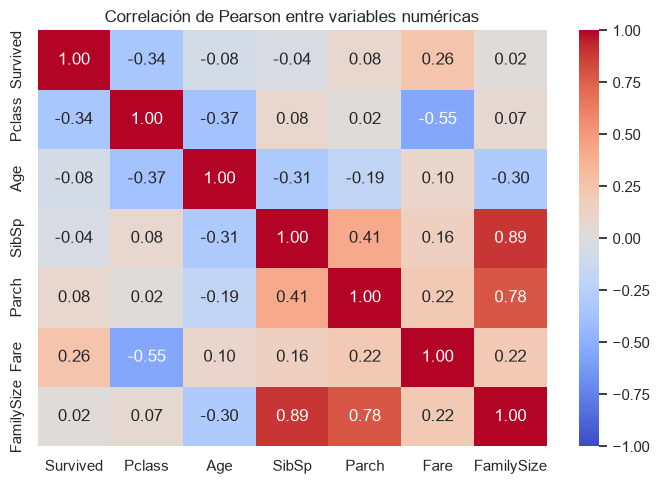

In [15]:
variables_numericas = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
matriz_corr = titanic_exp[variables_numericas].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación de Pearson entre variables numéricas")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f1_titanic_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación (relación entre preguntas y resultados observados):** `Survived` correlaciona negativamente con `Pclass` (a mayor número de clase, es decir, categoría más baja, menor supervivencia) y positivamente con `Fare`, lo que es consistente con los resultados bivariados anteriores. Entre las variables originales, las correlaciones son en general moderadas o bajas (la mayor es `Fare`–`Pclass`, −0.55). `FamilySize` muestra correlaciones altas con `SibSp` (0.89) y `Parch` (0.78), esperables por su construcción a partir de ambas variables y relevantes para su eventual uso conjunto en el modelado de fases posteriores.

---
## VII. Supuestos y limitaciones

### Supuestos considerados durante el análisis

- Se asume que el dataset es una muestra sin duplicados relevantes de pasajeros (`PassengerId` es único) y que los registros reflejan fielmente la información oficial disponible.
- La ausencia de valores en `Age` podría estar asociada a variables observadas como `Pclass` (apartado V); para `Cabin` no se evalúa el mecanismo de ausencia en esta fase, y su tratamiento se posterga principalmente por su elevada proporción de valores faltantes. Por ambas razones, ninguna de las dos se imputa de forma definitiva en esta fase.
- Se asume que la imputación puntual de `Embarked` (2 casos) con la moda no introduce sesgo relevante, dado su bajo peso relativo (0.22% del total).

### Limitaciones detectadas en los datos, el proceso o el alcance del avance

- `Cabin` tiene una tasa de valores faltantes demasiado alta (77.1%) para ser utilizada de forma directa; solo se aprovechó como indicador binario.
- `Age` faltante en el 19.9% de los casos limita la robustez de los análisis que la involucran; los resultados presentados para esta variable deben leerse como preliminares.
- El dataset corresponde a 891 pasajeros, un subconjunto del total de personas a bordo (2224), por lo que las proporciones observadas no deben extrapolarse sin matices al universo completo.
- No se realizaron pruebas estadísticas formales de asociación (por ejemplo, chi-cuadrado o pruebas de diferencia de medias); las lecturas de esta fase son exploratorias y descriptivas, no inferenciales.

### Aspectos pendientes que condicionan fases posteriores

- Definir e implementar la estrategia final de imputación de `Age` (por ejemplo, mediana condicionada por `Pclass` y `Title`).
- Decidir el tratamiento definitivo de `Cabin` (uso exclusivo del indicador binario, extracción de la cubierta, o exclusión de la variable).
- Evaluar la necesidad de tratar los valores atípicos detectados en `Fare`.
- Codificar variables categóricas y definir la partición de datos (train/test) para el modelado predictivo en fases posteriores.

---
## VIII. Cierre del avance

### Síntesis breve del trabajo realizado

En este primer avance se cargó y revisó el dataset Titanic (891 filas, 12 columnas), se cuantificó su calidad (valores faltantes en `Age`, `Cabin` y `Embarked`), se generaron estadísticas descriptivas y visualizaciones univariadas, se documentaron 5 decisiones exploratorias con su justificación y transformaciones asociadas (indicadores de completitud, tamaño familiar, indicador de viajar solo y título extraído del nombre), y se realizó un primer análisis bivariado entre estas variables y `Survived`, incluyendo la detección preliminar de valores atípicos mediante IQR.

### Principales hallazgos de la fase

- La tasa de supervivencia global es del 38.4%, con diferencias marcadas por sexo (mujeres ≈74% vs. hombres ≈19%) y por clase de pasaje (primera ≈63%, tercera ≈24%).
- `Fare` está asociada positivamente con la supervivencia y `Pclass` negativamente, de forma consistente con el patrón histórico conocido del hundimiento.
- Viajar acompañado (`IsAlone = 0`) se asocia a una mayor tasa de supervivencia que viajar solo.
- `Cabin` y `Age` requieren un tratamiento cuidadoso de valores faltantes en la siguiente fase: en `Age`, la proporción de faltantes varía según `Pclass`; en `Cabin`, el 77.1% de ausencia limita su uso directo.

### Proyección o continuidad esperada para las siguientes etapas del proyecto

Las fases posteriores deberán abordar: (a) la estrategia definitiva de imputación de valores faltantes, (b) la codificación de variables categóricas y la ingeniería de variables final, (c) la partición de los datos en conjuntos de entrenamiento y prueba, y (d) la implementación y evaluación de modelos predictivos orientados a estimar la probabilidad de supervivencia, retomando como base los hallazgos exploratorios documentados en este avance.